In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [2]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)   # 显示所有列
pd.set_option('expand_frame_repr', False)   # 不允许换行
pd.set_option('display.max_colwidth', 50)
pd.set_option('display.max_colwidth', None)
train_data = pd.read_csv('/kaggle/input/titanic/train.csv')
test_data = pd.read_csv('/kaggle/input/titanic/test.csv')
train_data.info()  
test_data.info()
print('train_data中的缺失值：', train_data.isnull().sum())
print('test_data中的缺失值：', test_data.isnull().sum())
train_data['Age'] = train_data['Age'].fillna(train_data['Age'].mean())
test_data['Age'] = test_data['Age'].fillna(test_data['Age'].mean())
train_data['Cabin'] = train_data['Cabin'].fillna(method='bfill') # bfill表示后一个值
train_data['Cabin'] = train_data['Cabin'].fillna(method='ffill') # ffill表示前一个值
test_data['Cabin'] = test_data['Cabin'].fillna(method='bfill')
test_data['Cabin'] = test_data['Cabin'].fillna(method='ffill')
train_data['Embarked'] = train_data['Embarked'].fillna('S')
train_data['Embarked'].value_counts()
test_data['Fare'] = test_data['Fare'].fillna(test_data['Fare'].mean())
full_data = pd.concat([train_data, test_data], axis=0).reset_index()
full_data = full_data.drop('index', axis=1)

print('full_data中的缺失值：', full_data.isnull().sum())
Sex_mapDict = {'male' : 1, 'female' : 0}
full_data['Sex'] = full_data['Sex'].map(Sex_mapDict)
full_data['Sex'] = full_data['Sex'].map({'male':1, 'female':0})
Pclass_df = pd.DataFrame()
Pclass_df = pd.get_dummies(full_data['Pclass'], prefix='Pclass')
full_data = pd.concat([full_data, Pclass_df], axis=1)
full_data = full_data.drop('Pclass', axis=1)
Embarked_df = pd.DataFrame()
Embarked_df = pd.get_dummies(full_data['Embarked'], prefix='Embarked')
full_data = pd.concat([full_data, Embarked_df], axis=1)
full_data = full_data.drop('Embarked', axis=1)
def GetTitle(name):              # 编写一个新的函数
    str1 = name.split(',')[1]    # 用逗号进行分割，1代表取后半部分
    str2 = str1.split('.')[0]    # 用句号进行分割，0代表取前半部分
    str3 = str2.strip()          # strip()用于移除指定的符号，这里默认为空格  
    return str3

Name_df = pd.DataFrame()
Name_df['Title'] = full_data['Name'].map(GetTitle)  # 再次用上述的map函数，将GetTitle映射到列['Name']

#  这一步，像Mr、Miss的就是正确的头衔，而Mlle、Dona等可能要进行自我判断一下，这里把所有的值都统一到几个常见的头衔
Title_mapDict = {'Mr': 'Mr',
                 'Miss': 'Miss',
                 'Mrs': 'Mrs',
                 'Master': 'Master',
                 'Dr': 'Officer',
                 'Rev': 'Officer',
                 'Col': 'Officer',
                 'Ms': 'Mrs',
                 'Major': 'Officer',
                 'Mlle': 'Miss',
                 'Jonkheer': 'Mr',
                 'Don': 'Mr',
                 'Lady': 'Mrs',
                 'the Countess': 'Royalty',
                 'Dona': 'Royalty',
                 'Capt': 'Royalty',
                 'Sir': 'Officer',
                 'Mme': 'Royalty',
                 }

Name_df['Title'] = Name_df['Title'].map(Title_mapDict)
Name_df = pd.get_dummies(Name_df['Title'], prefix='Title')
full_data = pd.concat([full_data, Name_df], axis=1)
full_data = full_data.drop('Name', axis=1)
full_data['Cabin'] = full_data['Cabin'].astype(str)            # 首先将这列转换为字符串类型
full_data['Cabin'] = full_data['Cabin'].map(lambda x : x[0])   # 接着用lambda函数实现提取首字符

Cabin_df = pd.DataFrame()
Cabin_df = pd.get_dummies(full_data['Cabin'], prefix='Cabin')

full_data = pd.concat([full_data, Cabin_df], axis=1)
full_data = full_data.drop('Cabin', axis=1)
Family_df = pd.DataFrame()
Family_df['Family'] = full_data['Parch'] + full_data['SibSp'] + 1
Family_df['Family_S'] = Family_df['Family'].map(lambda x : 1 if x == 1 else 0)
Family_df['Family_M'] = Family_df['Family'].map(lambda x : 1 if 2 <= x <= 3 else 0)
Family_df['Family_L'] = Family_df['Family'].map(lambda x : 1 if 4 < x < 5 else 0)
Family_df['Family_Xl'] = Family_df['Family'].map(lambda x : 1 if 5 < x else 0)


Family_df = Family_df.iloc[:, 1:]
full_data = pd.concat([full_data, Family_df], axis=1)
Fare_df = pd.DataFrame()
Fare_df['Fare'] = full_data['Fare']
Fare_df['Fare_Low'] = Fare_df['Fare'].map(lambda x : 1 if 0 <= x < 50 else 0)
Fare_df['Fare_Medium'] = Fare_df['Fare'].map(lambda x : 1 if 50 <= x < 100 else 0)
Fare_df['Fare_High'] = Fare_df['Fare'].map(lambda x : 1 if 100 < x else 0)

Fare_df = Fare_df.iloc[:, 1:]

full_data = pd.concat([full_data, Fare_df], axis=1)
full_data = full_data.drop('Fare', axis=1)
full_X = full_data.drop('PassengerId',axis=1)
full_X = full_X.drop('SibSp', axis=1)
full_X = full_X.drop('Parch', axis=1)
full_X = full_X.drop('Ticket', axis=1)
Row = 890
train_X = full_X.loc[0:Row, :]                 # 前891行，即原train数据集行数
train_X = train_X.drop('Survived', axis=1)     # 剔除'Survived'列
train_y = full_X.loc[0:Row, 'Survived']        # 原始train数据集行数

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass  

C=0.01时，交叉验证平均准确率: 0.6162 (±0.0023)
C=0.1时，交叉验证平均准确率: 0.7890 (±0.0219)
C=1时，交叉验证平均准确率: 0.8149 (±0.0365)
C=10时，交叉验证平均准确率: 0.8216 (±0.0339)
C=100时，交叉验证平均准确率: 0.8036 (±0.0326)

最优惩罚参数C: 10，对应准确率: 0.8216


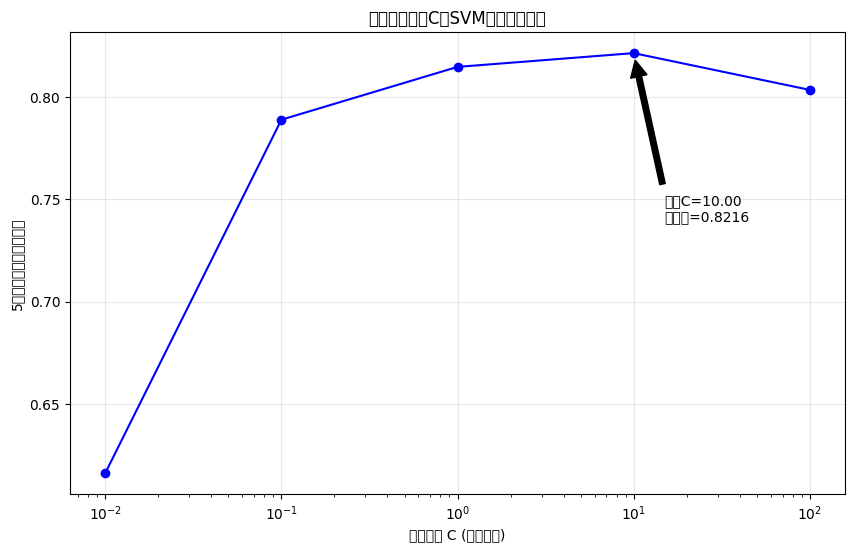

最优C值模型的预测结果已保存至 titanic_svm_best_c_submission.csv

特征重要性排序（通过置换重要性）:
         Feature  Importance
21     Title_Mrs    0.048036
18  Title_Master    0.035690
24    FamilySize    0.031762
1            Age    0.027834
13       Cabin_E    0.020539
7     Embarked_Q    0.017957
12       Cabin_D    0.017508
2           Fare    0.013468
4       Pclass_2    0.013468
5       Pclass_3    0.009652


In [3]:
#支持向量机 (SVM)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# 数据加载
train_data = pd.read_csv('/kaggle/input/titanic/train.csv')
test_data = pd.read_csv('/kaggle/input/titanic/test.csv')

# 合并数据便于统一处理
full_data = pd.concat([train_data, test_data], axis=0, ignore_index=True)

# -------------------- 1. 数据清洗 --------------------
# 填充缺失值
full_data['Age'] = full_data['Age'].fillna(full_data['Age'].median())
full_data['Fare'] = full_data['Fare'].fillna(full_data['Fare'].median())
full_data['Embarked'] = full_data['Embarked'].fillna('S')

# 处理Cabin（提取首字母并标记缺失值）
full_data['Cabin'] = full_data['Cabin'].apply(lambda x: str(x)[0] if pd.notna(x) else 'Unknown')

# -------------------- 2. 特征工程 --------------------
# 性别编码
full_data['Sex'] = full_data['Sex'].map({'male': 1, 'female': 0})

# 独热编码：Pclass, Embarked, Cabin
full_data = pd.get_dummies(full_data, columns=['Pclass', 'Embarked', 'Cabin'], prefix=['Pclass', 'Embarked', 'Cabin'])

# 从Name中提取Title
full_data['Title'] = full_data['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
title_mapping = {
    'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master',
    'Dr': 'Officer', 'Rev': 'Officer', 'Col': 'Officer', 'Mlle': 'Miss',
    'Major': 'Officer', 'Ms': 'Mrs', 'Lady': 'Mrs', 'Sir': 'Officer',
    'Mme': 'Mrs', 'Countess': 'Royalty', 'Don': 'Royalty', 'Dona': 'Royalty'
}
full_data['Title'] = full_data['Title'].map(title_mapping)
full_data = pd.get_dummies(full_data, columns=['Title'], prefix='Title')

# 构造家庭规模特征
full_data['FamilySize'] = full_data['SibSp'] + full_data['Parch'] + 1
full_data['IsAlone'] = (full_data['FamilySize'] == 1).astype(int)

# 删除无用列
drop_columns = ['Name', 'Ticket', 'SibSp', 'Parch', 'PassengerId']
full_data = full_data.drop(drop_columns, axis=1)

# -------------------- 3. 数据标准化（SVM对尺度敏感！）--------------------
# 划分训练集和测试集
train = full_data[~full_data['Survived'].isna()]
test = full_data[full_data['Survived'].isna()].drop('Survived', axis=1)

X = train.drop('Survived', axis=1)
y = train['Survived']

# 标准化特征（必须做，否则SVM性能会下降）
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
test_scaled = scaler.transform(test)

# 假设已有数据预处理后的X_scaled, y, test_scaled, test_data

# -------------------- 4. SVM模型训练与参数对比 --------------------
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import pandas as pd

# 定义不同惩罚参数C
c_values = [0.01, 0.1, 1, 10, 100]
cv_accuracies = []

# 对每个C值进行交叉验证
for c in c_values:
    svm_model = SVC(
        kernel='rbf',
        C=c,
        gamma='scale',
        random_state=42,
        probability=True
    )
    scores = cross_val_score(svm_model, X_scaled, y, cv=5)
    cv_accuracies.append(scores.mean())
    print(f"C={c}时，交叉验证平均准确率: {scores.mean():.4f} (±{scores.std():.4f})")

# 找到最优C值
best_c_idx = np.argmax(cv_accuracies)
best_c = c_values[best_c_idx]
print(f"\n最优惩罚参数C: {best_c}，对应准确率: {cv_accuracies[best_c_idx]:.4f}")

# -------------------- 5. 可视化不同C值的效果 --------------------
plt.figure(figsize=(10, 6))
plt.plot(c_values, cv_accuracies, marker='o', linestyle='-', color='blue')
plt.xscale('log')  # 对数刻度显示C值
plt.title('不同惩罚参数C对SVM准确率的影响')
plt.xlabel('惩罚参数 C (对数刻度)')
plt.ylabel('5折交叉验证平均准确率')
plt.grid(True, alpha=0.3)
plt.annotate(f'最优C={best_c:.2f}\n准确率={cv_accuracies[best_c_idx]:.4f}',
             xy=(best_c, cv_accuracies[best_c_idx]),
             xytext=(best_c*1.5, cv_accuracies[best_c_idx]*0.9),
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.savefig('svm_c_comparison.png')
plt.show()

# -------------------- 6. 用最优C值训练最终模型 --------------------
best_svm_model = SVC(
    kernel='rbf',
    C=best_c,
    gamma='scale',
    random_state=42,
    probability=True
)
best_svm_model.fit(X_scaled, y)

# -------------------- 7. 预测与生成提交文件 --------------------
# 预测测试集
test_predictions = best_svm_model.predict(test_scaled)

# 生成提交文件
submission = pd.DataFrame({
    'PassengerId': test_data['PassengerId'],
    'Survived': test_predictions.astype(int)
})
submission.to_csv('titanic_svm_best_c_submission.csv', index=False)
print("最优C值模型的预测结果已保存至 titanic_svm_best_c_submission.csv")

# -------------------- 8. 特征重要性分析 --------------------
from sklearn.inspection import permutation_importance

result = permutation_importance(best_svm_model, X_scaled, y, n_repeats=10, random_state=42)
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': result.importances_mean
}).sort_values('Importance', ascending=False)
print("\n特征重要性排序（通过置换重要性）:")
print(importance_df.head(10))